[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

### Lecture 6 Time-series
- AR(1) model
- filtering - trend

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import statsmodels.tsa.stattools as stattools

## AR(1) model

Fit the AR(1) model

$$ X_t = \phi X_{t-1} + W_t + k $$

where $W_t$ is white noise. Let's set $k = 0$:

$$ X_t = \phi X_{t-1} + W_t $$

- read data and organize the data to give a date column

In [ ]:
df = pd.read_csv("./noaa_roni.csv")
seasons = ["DJF","JFM","FMA","MAM","AMJ","MJJ","JJA","JAS","ASO","SON","OND","NDJ"]
season_to_month = {s: i+1 for i, s in enumerate(seasons)}
df["month_idx"] = df["Season"].map(season_to_month)
df["date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["month_idx"].astype(str) + "-01")



- calculate a lag-1 autocorrelation

In [28]:
roni = df["RONI"].values
rho   = stattools.acf(roni, nlags=1, adjusted=False)

- calculate sigmaW for lage 1

In [29]:
phi_hat = rho[1]
x_hat = phi_hat * roni[:-1]
residuals = roni[1:] - x_hat
sigma_W_hat = residuals.std()
print(sigma_W_hat)

0.2095252942800356


 ### build an AR(1) ENSO model with lead time from 1 to 12 months

- give a initial date and set X0, lead times

In [30]:
idx = np.where(df['date'] == '1997-07-01')[0][0]
x0 = roni[idx]
forecast_horizon = 12 ## month
t_ahead = np.arange(0, forecast_horizon + 1) ### time index

- the general distribution of $x_t$

$$
p(x_t \mid x_0) \sim N\left(\phi^t x_0,\ \sigma_W^2 \frac{1-\phi^{2t}}{1-\phi}\right)
$$

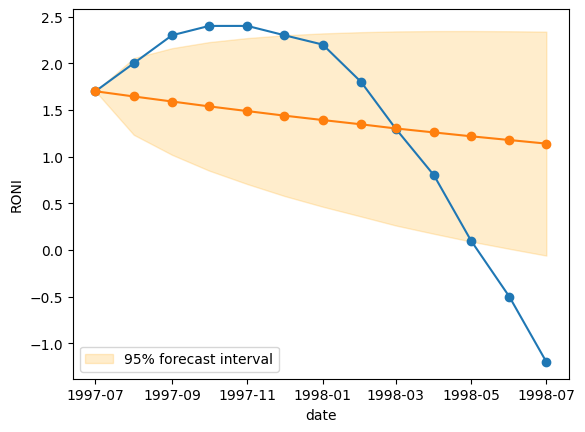

In [31]:
x_hat_mean = phi_hat**t_ahead * x0
x_hat_var = sigma_W_hat**2 * (1 - phi_hat**(2*t_ahead)) / (1 - phi_hat**2)
x_hat_var[0] = 0
x_hat_std = np.sqrt(x_hat_var)
plt.plot(df['date'][idx:idx+forecast_horizon+1],roni[idx:idx+forecast_horizon+1],'o-')
plt.plot(df['date'][idx:idx+forecast_horizon+1],x_hat_mean,'o-')
plt.fill_between(df['date'][idx:idx+forecast_horizon+1],x_hat_mean - 1.96*x_hat_std, x_hat_mean + 1.96*x_hat_std,color='orange', alpha=0.2, label='95% forecast interval')
plt.xlabel('date')
plt.ylabel('RONI')
plt.savefig('ENSO_AR1_exp3.png')
plt.legend()

-try other dates

- let's plot theoretical (model) and observed (data) ACF

In [32]:
max_lag = 12
rho = stattools.acf(roni, nlags=max_lag, adjusted=False)[1:] ### from data



In [33]:
acf_model = phi_hat ** np.arange(1,max_lag+1)   # theoretical ACF of an AR(1): rho_tau = phi^tau

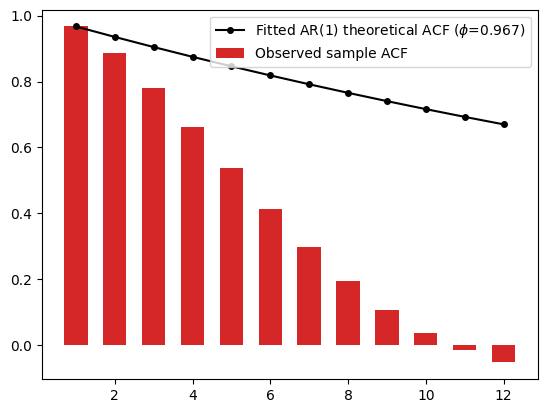

In [34]:
plt.bar(np.arange(1,max_lag+1), rho, color='tab:red', width=0.6, label='Observed sample ACF')
plt.plot(np.arange(1,max_lag+1), acf_model, color='black', marker='o', ms=4, lw=1.5,
         label=f'Fitted AR(1) theoretical ACF ($\\phi$={phi_hat:.3f})')
plt.legend()

-- hands on --

In [27]:
df = pd.read_csv("./nyc_tmax_anomaly_2000_2005.csv", parse_dates=["DATE"])
df

FileNotFoundError: [Errno 2] No such file or directory: './nyc_tmax_anomaly_2000_2005.csv'

- get NASA GISTEMP

In [35]:
df = pd.read_csv("./NASA_GISTEMP.csv", parse_dates=["date"])
df

FileNotFoundError: [Errno 2] No such file or directory: './NASA_GISTEMP.csv'

- let's get x (anomaly), length (n), and index (t), and tbar; tbar is for the SE later

In [ ]:

anomaly = df["Anomaly"].values
n = len(anomaly)
t = np.arange(n)
tbar = t.mean()




- we are going to use 1 degree polynomial fit

In [ ]:
coefs = np.polyfit(t, anomaly, 1)
slope, intercept = coefs
## using poly1d
trend_poly = np.poly1d(coefs)(t)
## or directly claculate it
trend = intercept+slope*t

resid = anomaly - trend



In [ ]:
# Convert slope to per-year (since x_idx is in months)
slope_per_year = slope * 12

print(f"Warming trend: {slope_per_year:.4f} °C/year")


- lets calcualte the SE for slope using naive N

In [ ]:
ss_t = np.sum((t - tbar)**2)
dof_naive = n - 2
sigma_hat_naive = np.sqrt(np.sum(resid**2) / dof_naive)
se_slope_naive = sigma_hat_naive / np.sqrt(ss_t)
t_crit_naive = stats.t.ppf(0.975, dof_naive)
ci_naive = se_slope_naive*t_crit_naive

print(f"Naive N Slope: {slope_per_year:.4f} +/- {ci_naive*12:.4f} °C/year")

- For linear regression, the effective N is calculated using the autocorrelation function of the residuals.

In [ ]:


rho1   = stattools.acf(resid, nlags=1, adjusted=False)[1]

n_eff = n * (1 - rho1) / (1 + rho1)
scale = np.sqrt(n / n_eff)
se_slope_corrected = se_slope_naive * scale
dof_corrected = n_eff - 2
t_crit_corrected = stats.t.ppf(0.975, dof_corrected)
ci_corrected = t_crit_corrected * se_slope_corrected

print(f"Effective N {n_eff:.4f} Slope: {slope_per_year:.4f} +/- {ci_corrected *12:.4f} °C/year")

In [ ]:
# Max gap occurs at the last point (t = n-1)
max_halfwidth = ci_corrected * (n - 1)
print(f"Max half-width (at t={n_eff-1}) = {max_halfwidth:.4f} degC")

# Constant band: same +/- half-width applied at every t
const_lower = trend - max_halfwidth
const_upper = trend + max_halfwidth



In [ ]:
# Max gap occurs at the last point (t = n-1)
max_halfwidth_naive = se_slope_naive*t_crit_naive * (n - 1)
print(f"Max half-width (at t={n-1}) = {max_halfwidth_naive:.4f} degC")

# Constant band: same +/- half-width applied at every t
const_lower_naive = trend - max_halfwidth_naive
const_upper_naive = trend + max_halfwidth_naive


In [ ]:

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df["date"], anomaly, color="firebrick", linewidth=0.7, alpha=0.65, label="GISTEMP anomaly")
ax.plot(df["date"], trend, color="black", linewidth=2, label=f"Fitted trend ({slope*120:.4f} °C/decade)")
ax.fill_between(df["date"], const_lower_naive, const_upper_naive, color="pink", alpha=0.5,
                 label=f"Constant ±{max_halfwidth_naive:.3f} °C band (N)")
ax.fill_between(df["date"], const_lower, const_upper, color="steelblue", alpha=0.2,
                 label=f"Constant ±{max_halfwidth:.3f} °C band (effective N)")

ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("GISTEMP Trend: Constant-Width Example Band, 1990-2025")
ax.set_xlabel("Date")
ax.set_ylabel("Anomaly (°C)")
ax.legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("gistemp_trend_constant_band.png", dpi=150)
plt.show()

-- hands on --

In [ ]:
df = pd.read_csv("./NYC_data.csv", parse_dates=["DATE"])
df = df.dropna(subset=["TMAX"]).sort_values("DATE").reset_index(drop=True)
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month
df["TMAX_C"] = (df["TMAX"] - 32) * 5/9   # Fahrenheit -> Celsius

In [ ]:
month = 7
sub = df[df["Month"] == month]
counts = sub.groupby("Year")["TMAX_C"].count()
yearly = sub.groupby("Year")["TMAX_C"].mean().reset_index()
yearly = yearly[yearly["Year"].isin(counts[counts >= 20].index)].reset_index(drop=True)

years = yearly["Year"].values
y = yearly["TMAX_C"].values
n = len(y)
t = np.arange(n)

In [ ]:
y